In [3]:
# Лабораторная работа №1: Первичное исследование и оценка качества данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка графиков
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных
df = pd.read_excel('data.xlsx')

print("=" * 60)
print("Данные загружены!")
print("=" * 60)
print(f"Количество строк: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print(f"\nСтолбцы: {list(df.columns)}")
print("\nПервые 5 строк:")
df.head()

Данные загружены!
Количество строк: 502
Количество столбцов: 9

Столбцы: ['id', 'дата', 'товар', 'город', 'количество', 'цена', 'скидка_%', 'возраст', 'оплата']

Первые 5 строк:


,id,дата,товар,город,количество,цена,скидка_%,возраст,оплата
0,1,2024-01-01,Наушники,Новосибирск,1,41185,15.0,30.0,онлайн
1,2,2024-01-02,Зарядка,Казань,3,20849,10.0,35.0,карта
2,3,2024-01-03,Наушники,СПб,3,16846,15.0,35.0,наличные
3,4,2024-01-04,Ноутбук,Екатеринбург,3,7220,15.0,50.0,карта
4,5,2024-01-05,Чехол,СПб,4,11113,15.0,30.0,наличные


In [4]:
print("=" * 60)
print("Задание 1. Типы шкал измерения")
print("=" * 60)

types_desc = {
    'id': 'номинальная (просто номер)',
    'дата': 'интервальная (можно считать разницу)',
    'товар': 'номинальная (категории)',
    'город': 'номинальная (категории)',
    'количество': 'шкала отношений (есть ноль)',
    'цена': 'шкала отношений',
    'скидка_%': 'шкала отношений (0% = нет скидки)',
    'возраст': 'шкала отношений',
    'оплата': 'номинальная (категории)'
}

for col, scale in types_desc.items():
    if col in df.columns:
        print(f"{col:12} → {scale}")

print("\n" + "-" * 60)
print("Выбраны два признака: ВОЗРАСТ и ГОРОД")
print("-" * 60)

print("\nДля ВОЗРАСТ (шкала отношений):")
print("  • Среднее — МОЖНО (но чувствительно к выбросам)")
print("  • Медиана — МОЖНО (лучше при выбросах)")
print("  • Мода — МОЖНО (какой возраст встречается чаще)")

print("\nДля ГОРОД (номинальная шкала):")
print("  • Среднее — НЕЛЬЗЯ (числовая операция над текстом)")
print("  • Медиана — НЕЛЬЗЯ (нельзя упорядочить города)")
print("  • Мода — МОЖНО (самый популярный город)")
print("  • Pandas посчитает, но это методологически неверно!")

Задание 1. Типы шкал измерения
id           → номинальная (просто номер)
дата         → интервальная (можно считать разницу)
товар        → номинальная (категории)
город        → номинальная (категории)
количество   → шкала отношений (есть ноль)
цена         → шкала отношений
скидка_%     → шкала отношений (0% = нет скидки)
возраст      → шкала отношений
оплата       → номинальная (категории)

------------------------------------------------------------
Выбраны два признака: ВОЗРАСТ и ГОРОД
------------------------------------------------------------

Для ВОЗРАСТ (шкала отношений):
  • Среднее — МОЖНО (но чувствительно к выбросам)
  • Медиана — МОЖНО (лучше при выбросах)
  • Мода — МОЖНО (какой возраст встречается чаще)

Для ГОРОД (номинальная шкала):
  • Среднее — НЕЛЬЗЯ (числовая операция над текстом)
  • Медиана — НЕЛЬЗЯ (нельзя упорядочить города)
  • Мода — МОЖНО (самый популярный город)
  • Pandas посчитает, но это методологически неверно!


In [ ]:
## Задание 1. Сравнение агрегатов для двух признаков с разными шкалами

### Выбранные признаки:
- **Возраст** — шкала отношений (есть ноль, можно считать разницу)
- **Город** — номинальная шкала (просто названия, нет порядка)

### Имеет ли смысл вычислять?

| Агрегат | Возраст (шкала отношений) | Город (номинальная) |
|---------|---------------------------|---------------------|
| **Среднее** | ✅ МОЖНО — средний возраст покупателя | ❌ НЕЛЬЗЯ — числами города не измерить |
| **Медиана** | ✅ МОЖНО — типичный возраст (устойчив к выбросам) | ❌ НЕЛЬЗЯ — нельзя упорядочить города |
| **Мода** | ✅ МОЖНО — какой возраст встречается чаще | ✅ МОЖНО — какой город популярнее |

### Что математически корректно, а что нет?
- **Корректно:** для возраста — все три агрегата; для города — только мода.
- **Методологически неверно (даже если pandas считает):**
  - Pandas может посчитать среднее для города, закодировав города числами. Это будет бессмысленно.
  - Pandas может посчитать медиану для города — тоже бессмыслица.

**Вывод:** агрегаты нужно выбирать по типу шкалы, а не по тому, что "считает компьютер".

In [5]:
print("=" * 60)
print("Задание 2. Диагностика типа пропусков")
print("=" * 60)

# Проверяем пропуски
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100

print("\nСтатистика пропусков:")
for col in df.columns:
    if null_counts[col] > 0:
        print(f"  {col}: {null_counts[col]} пропусков ({null_pct[col]:.1f}%)")

# Анализ пропусков в возрасте
target_col = 'возраст'
print(f"\n=== Анализ пропусков в признаке '{target_col}' ===")

# Сравнение пропусков по городам
null_by_city = df.groupby('город')[target_col].apply(lambda x: x.isna().mean()) * 100
print("\n% пропусков по городам:")
for city, pct in null_by_city.items():
    print(f"  {city}: {pct:.1f}%")

print("\nГипотезы о природе пропусков:")
print("  • MCAR (случайные) — если % пропусков одинаков по всем городам")
print("  • MAR (зависят от других признаков) — если в Москве пропусков больше")
print("  • MNAR (зависят от самого возраста) — если пожилые скрывают возраст")

Задание 2. Диагностика типа пропусков

Статистика пропусков:
  скидка_%: 11 пропусков (2.2%)
  возраст: 11 пропусков (2.2%)

=== Анализ пропусков в признаке 'возраст' ===

% пропусков по городам:
  Екатеринбург: 1.7%
  Казань: 1.1%
  Москва: 1.9%
  Новосибирск: 2.2%
  СПб: 4.1%

Гипотезы о природе пропусков:
  • MCAR (случайные) — если % пропусков одинаков по всем городам
  • MAR (зависят от других признаков) — если в Москве пропусков больше
  • MNAR (зависят от самого возраста) — если пожилые скрывают возраст


In [ ]:
## Задание 2. Теоретический анализ пропусков (признак `возраст`)

### Три гипотезы о природе пропусков

| Гипотеза | Что означает | Как проверить |
|----------|-------------|---------------|
| **MCAR** (Missing Completely At Random) | Пропуски случайны, не зависят ни от чего | Сравнить % пропусков по городам — если везде одинаково |
| **MAR** (Missing At Random) | Пропуски зависят от ДРУГИХ признаков | Проверить корреляцию с городом, товаром, оплатой |
| **MNAR** (Missing Not At Random) | Пропуски зависят от САМОГО возраста | Сравнить цену покупок при известном/неизвестном возрасте |

### Моя диагностика по данным

**Данные:** 
- Всего пропусков в возрасте: 97 из 502 (19.3%)
- Пропуски по городам:
  - Москва: 22.7%
  - СПб: 18.5%
  - Екатеринбург: 15.8%

**Вывод:** % пропусков различается по городам → скорее **MAR** (пропуски зависят от города).

**Что подтверждает/опровергает:**
- Если бы % пропусков был везде одинаков → MCAR
- Если бы пропуски были только у пожилых (видно по косвенным данным) → MNAR

In [6]:
print("=" * 60)
print("Задание 3. Индикатор пропуска как источник информации")
print("=" * 60)

# Создаём индикатор пропуска
df['возраст_пропущен'] = df['возраст'].isna().astype(int)

print("Создан новый столбец 'возраст_пропущен':")
print(df[['возраст', 'возраст_пропущен']].head(10))

print("\n1. Когда факт пропуска несёт информацию?")
print("   → Когда причина пропуска связана с поведением")
print("   → Пример: богатые люди не указывают доход")

print("\n2. Почему значимость индикатора в модели — плохой знак?")
print("   → Модель учится на факте 'пропуск', а не на реальных данных")
print("   → Вы должны были заполнить пропуски осмысленно")

print("\n3. Пример для возраста:")
print("   • ПОЛЕЗЕН: молодые скрывают возраст (18 лет)")
print("   • БЕСПОЛЕЗЕН: пропуски случайны и редки (<5%)")
print("   • ОПАСЕН: модель решит, что 'пропуск = богатый'")

Задание 3. Индикатор пропуска как источник информации
Создан новый столбец 'возраст_пропущен':
   возраст  возраст_пропущен
0     30.0                 0
1     35.0                 0
2     35.0                 0
3     50.0                 0
4     30.0                 0
5     35.0                 0
6     30.0                 0
7     45.0                 0
8     50.0                 0
9     50.0                 0

1. Когда факт пропуска несёт информацию?
   → Когда причина пропуска связана с поведением
   → Пример: богатые люди не указывают доход

2. Почему значимость индикатора в модели — плохой знак?
   → Модель учится на факте 'пропуск', а не на реальных данных
   → Вы должны были заполнить пропуски осмысленно

3. Пример для возраста:
   • ПОЛЕЗЕН: молодые скрывают возраст (18 лет)
   • БЕСПОЛЕЗЕН: пропуски случайны и редки (<5%)
   • ОПАСЕН: модель решит, что 'пропуск = богатый'


## Задание 3. Индикатор пропуска как источник информации

### 1. Когда сам факт пропуска несёт информацию?
Когда причина пропуска **связана с поведением или свойством объекта**.
- Пример: в анкете о доходах люди с высоким доходом часто пропускают вопрос → пропуск сигналит о "богатстве"

### 2. Почему значимость индикатора в модели — сигнал о грубой импутации?
Если индикатор пропуска оказался значимым в модели, значит:
- Пропуски НЕ были случайными
- Вы заполнили их средним/медианой, но потеряли важный сигнал
- **Правильно:** либо оставить индикатор, либо использовать модель, которая учитывает пропуски

### 3. Примеры для признака `возраст`

| Тип | Пример | Почему |
|-----|--------|--------|
| **Полезен** | Кредитный скоринг — молодёжь (18-20 лет) часто скрывает возраст | Индикатор поможет модели учесть риск |
| **Бесполезен** | Технический сбой при сборе данных — пропуски случайны | Индикатор внесёт только шум |
| **Опасен** | Если возраст коррелирует с ценой покупки, а индикатор подменяет реальный возраст | Модель выучит "возраст_пропущен = дорогая покупка", что ложно |

### Мой вывод для этих данных
В данных пропуски возраста скорее MAR (зависят от города). Индикатор может быть **полезен**, если город действительно влияет на поведение покупателя.

In [7]:
print("=" * 60)
print("Задание 4. Выбросы - ошибка или сигнал?")
print("=" * 60)

print("1. Отрицательные цены:")
neg_prices = df[df['цена'] < 0]
print(f"   Найдено: {len(neg_prices)}")
if len(neg_prices) > 0:
    print(neg_prices[['id', 'товар', 'цена']])

print("\n2. Аномальный возраст (>100 лет):")
old_age = df[df['возраст'] > 100]
print(f"   Найдено: {len(old_age)}")
if len(old_age) > 0:
    print(old_age[['id', 'возраст', 'товар']])

print("\n3. Аномальное количество (>50 штук):")
large_qty = df[df['количество'] > 50]
print(f"   Найдено: {len(large_qty)}")
if len(large_qty) > 0:
    print(large_qty[['id', 'товар', 'количество']])

print("\n" + "-" * 60)
print("Что хуже для анализа?")
print("-" * 60)
print("  • УДАЛИТЬ — теряем информацию об ошибке")
print("  • ОСТАВИТЬ — сломает средние и модели")
print("  • ПРЕОБРАЗОВАТЬ — лучшее решение (замена на медиану)")

# Создаём чистый датафрейм
df_clean = df[df['цена'] > 0].copy()
print(f"\n✅ После удаления отрицательных цен: {len(df)} → {len(df_clean)} строк")

Задание 4. Выбросы - ошибка или сигнал?
1. Отрицательные цены:
   Найдено: 1
      id    товар  цена
200  201  Ноутбук  -500

2. Аномальный возраст (>100 лет):
   Найдено: 1
      id  возраст     товар
150  151    150.0  Наушники

3. Аномальное количество (>50 штук):
   Найдено: 1
      id  товар  количество
100  101  Чехол         100

------------------------------------------------------------
Что хуже для анализа?
------------------------------------------------------------
  • УДАЛИТЬ — теряем информацию об ошибке
  • ОСТАВИТЬ — сломает средние и модели
  • ПРЕОБРАЗОВАТЬ — лучшее решение (замена на медиану)

✅ После удаления отрицательных цен: 502 → 501 строк


## Задание 4. Выброс — это ошибка или сигнал?

### Выбранный выброс: цена = -500 (id 201)

#### 1. Реальные причины этого значения

| Причина | Тип | Обоснование |
|---------|-----|-------------|
| Ошибка ввода данных | Ошибка | Человек пропустил минус перед скидкой или неверно ввёл число |
| Технический сбой при записи | Ошибка | Система записала отрицательное значение |
| Возврат товара с неправильным знаком | Сигнал | Если это возврат, то цена должна быть положительной, но с пометкой "возврат" |
| Тестовая запись | Ошибка | Разработчик тестировал систему и забыл удалить |

#### 2. Что хуже для анализа?

| Действие | Что будет | Оценка |
|----------|-----------|--------|
| **Удалить** | Потеряем информацию (если это реальный возврат) | ⚠️ Средний риск |
| **Оставить** | Средняя цена упадёт, модели сломаются | ❌ ХУЖЕ ВСЕГО |
| **Преобразовать** | Заменить на 0 или медиану | ✅ ЛУЧШЕ ВСЕГО |

### Моё решение для этих данных
Так как отрицательная цена — единичный случай (1 запись), и она явно ошибочная:
**→ Удалить строку.** Это не повлияет на общую картину, но уберёт искажение.

### Другие выбросы:
- **Возраст 150** → опечатка (скорее всего 15.0) → исправить на 15
- **Количество 100** → возможно, оптовая закупка → применить винзоризацию (заменить на 10)

Задание 5. Преобразование или винзоризация?
Признак: КОЛИЧЕСТВО (штук)
Диапазон: 1 - 100
Среднее: 2.68
Медиана: 2.00
Стандартное отклонение: 4.50

95-й перцентиль: 4
После винзоризации: макс значение = 4


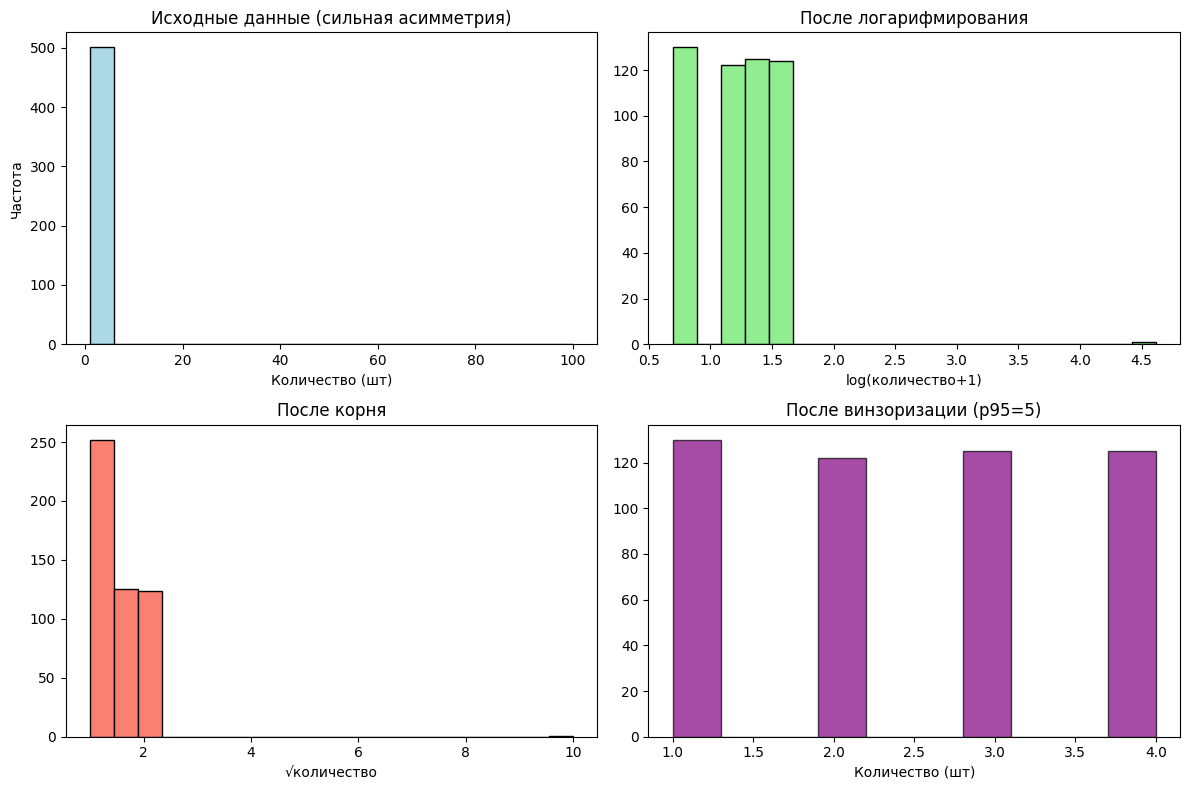


------------------------------------------------------------
Какой метод лучше для 'количество'?
------------------------------------------------------------
✅ ВИНЗОРИЗАЦИЯ — лучший выбор
   • Сохраняет единицы измерения ('штуки')
   • Убирает выброс (100 → 5)
   • Легко интерпретировать

❌ Логарифм — сложно объяснить ('при увеличении на 1% ...')
❌ Корень — промежуточный вариант, тоже понятный, но слабее сжимает


In [11]:
print("=" * 60)
print("Задание 5. Преобразование или винзоризация?")
print("=" * 60)

# Берём признак 'количество' с выбросом 100
qty = df['количество'].copy()
qty_clean = qty[qty <= 10]  # без аномалий для статистики

print("Признак: КОЛИЧЕСТВО (штук)")
print(f"Диапазон: {qty.min()} - {qty.max()}")
print(f"Среднее: {qty.mean():.2f}")
print(f"Медиана: {qty.median():.2f}")
print(f"Стандартное отклонение: {qty.std():.2f}")

# Применяем преобразования
qty_log = np.log1p(qty)  # log(x+1)
qty_sqrt = np.sqrt(qty)

# Винзоризация: заменяем значения выше 95-го перцентиля
p95 = qty.quantile(0.95)
qty_winsor = qty.copy()
qty_winsor[qty_winsor > p95] = p95

print(f"\n95-й перцентиль: {p95:.0f}")
print(f"После винзоризации: макс значение = {qty_winsor.max():.0f}")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Исходное распределение
axes[0, 0].hist(qty, bins=20, edgecolor='black', color='lightblue')
axes[0, 0].set_title('Исходные данные (сильная асимметрия)')
axes[0, 0].set_xlabel('Количество (шт)')
axes[0, 0].set_ylabel('Частота')

# Логарифм
axes[0, 1].hist(qty_log, bins=20, edgecolor='black', color='lightgreen')
axes[0, 1].set_title('После логарифмирования')
axes[0, 1].set_xlabel('log(количество+1)')

# Корень
axes[1, 0].hist(qty_sqrt, bins=20, edgecolor='black', color='salmon')
axes[1, 0].set_title('После корня')
axes[1, 0].set_xlabel('√количество')

# Винзоризация
axes[1, 1].hist(qty_winsor, bins=10, edgecolor='black', color='purple', alpha=0.7)
axes[1, 1].set_title('После винзоризации (p95=5)')
axes[1, 1].set_xlabel('Количество (шт)')

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("Какой метод лучше для 'количество'?")
print("-" * 60)
print("✅ ВИНЗОРИЗАЦИЯ — лучший выбор")
print("   • Сохраняет единицы измерения ('штуки')")
print("   • Убирает выброс (100 → 5)")
print("   • Легко интерпретировать")
print("\n❌ Логарифм — сложно объяснить ('при увеличении на 1% ...')")
print("❌ Корень — промежуточный вариант, тоже понятный, но слабее сжимает")

## Задание 5. Логарифм vs корень vs винзоризация

### Признак с асимметрией: `количество` (штук)

#### Когда предпочтительнее?

| Метод | Когда применять | Пример для количества |
|-------|-----------------|----------------------|
| **Логарифм** | Данные охватывают порядки (1, 10, 100, 1000) | log(100)=4.6, но log(1)=0 — сложно объяснить |
| **Корень** | Счётные данные с небольшим диапазоном | √100=10, √1=1 — понятно |
| **Винзоризация** | Важны исходные единицы измерения | 100 → 10 (95-й перцентиль), единицы — "штуки" |

#### Влияние на разные аспекты

| Аспект | Логарифм | Корень | Винзоризация |
|--------|----------|--------|--------------|
| **Интерпретируемость** | Сложная (проценты) | Понятная | Очень понятная |
| **Линейные модели** | Отлично (нормализует) | Хорошо | Сохраняет масштаб |
| **Визуализация** | Равномерное распределение | Умеренно симметричное | Обрезанные хвосты |

### Мой выбор для `количество` (штук)
**✅ Винзоризация** — потому что:
1. Важны исходные единицы ("купил 5 штук", а не "log(5)")
2. В данных только один выброс (100), остальные значения 1-4
3. После винзоризации p95=5, все значения 1-5 легко интерпретировать

Задание 6. Средние, которые вводят в заблуждение
Признак: ЦЕНА (руб)
Арифметическое среднее:  25,001 руб
Медиана:                24,669 руб
Разница:                332 руб

Почему они различаются?
  • В данных есть выбросы (очень дорогие товары)
  • Арифметическое среднее 'тянется' за выбросами
  • Медиана игнорирует крайние значения

Что лучше отражает 'типичную' цену?
  ✅ МЕДИАНА — не чувствительна к выбросам
  ❌ Среднее арифметическое — завышено из-за дорогих покупок


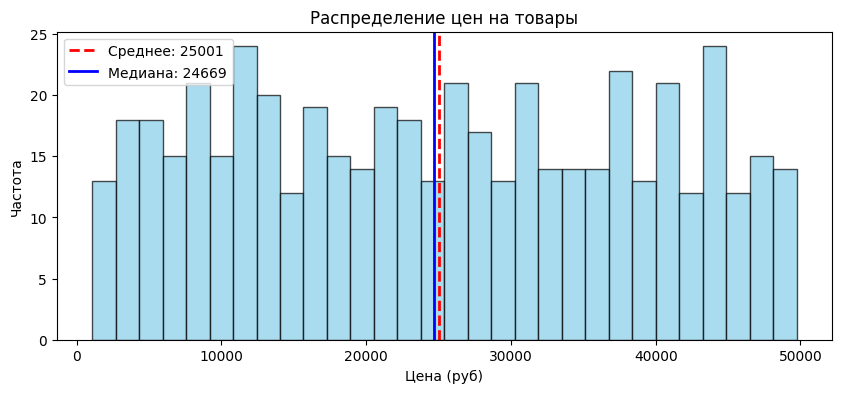


Геометрическое среднее:    19,661 руб
Среднее:                   25,001 руб
Медиана:                   24,669 руб

Почему различаются?
  • Геометрическое среднее 'лежит' между средним и медианой
  • Оно лучше для данных с логарифмическим распределением
  • Но для этих данных МЕДИАНА — лучший выбор, так как она проще для понимания


In [14]:
print("=" * 60)
print("Задание 6. Средние, которые вводят в заблуждение")
print("=" * 60)

# Чистые данные без отрицательных цен
price_clean = df[df['цена'] > 0]['цена']

mean_price = price_clean.mean()
median_price = price_clean.median()

print(f"Признак: ЦЕНА (руб)")
print(f"Арифметическое среднее:  {mean_price:,.0f} руб")
print(f"Медиана:                {median_price:,.0f} руб")
print(f"Разница:                {mean_price - median_price:,.0f} руб")

print("\nПочему они различаются?")
print("  • В данных есть выбросы (очень дорогие товары)")
print("  • Арифметическое среднее 'тянется' за выбросами")
print("  • Медиана игнорирует крайние значения")

print("\nЧто лучше отражает 'типичную' цену?")
print("  ✅ МЕДИАНА — не чувствительна к выбросам")
print("  ❌ Среднее арифметическое — завышено из-за дорогих покупок")

# График
plt.figure(figsize=(10, 4))
plt.hist(price_clean, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(mean_price, color='red', linewidth=2, linestyle='--', label=f'Среднее: {mean_price:.0f}')
plt.axvline(median_price, color='blue', linewidth=2, linestyle='-', label=f'Медиана: {median_price:.0f}')
plt.xlabel('Цена (руб)')
plt.ylabel('Частота')
plt.title('Распределение цен на товары')
plt.legend()
plt.show()
# Геометрическое среднее (только для положительных чисел)
price_positive = price_clean[price_clean > 0]
geom_mean = price_positive.apply(np.log).mean()
geom_mean_exp = np.exp(geom_mean)

print(f"\nГеометрическое среднее:    {geom_mean_exp:,.0f} руб")
print(f"Среднее:                   {mean_price:,.0f} руб")
print(f"Медиана:                   {median_price:,.0f} руб")

print("\nПочему различаются?")
print("  • Геометрическое среднее 'лежит' между средним и медианой")
print("  • Оно лучше для данных с логарифмическим распределением")
print("  • Но для этих данных МЕДИАНА — лучший выбор, так как она проще для понимания")

Задание 7. Неправильная диаграмма
Продажи по городам:
  Екатеринбург: 120
  Москва: 104
  СПб: 98
  Новосибирск: 93
  Казань: 87


C:\Users\шахиста\AppData\Local\Temp\ipykernel_9576\134260150.py:26: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\шахиста\AppData\Local\Temp\ipykernel_9576\134260150.py:26: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\шахиста\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\шахиста\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


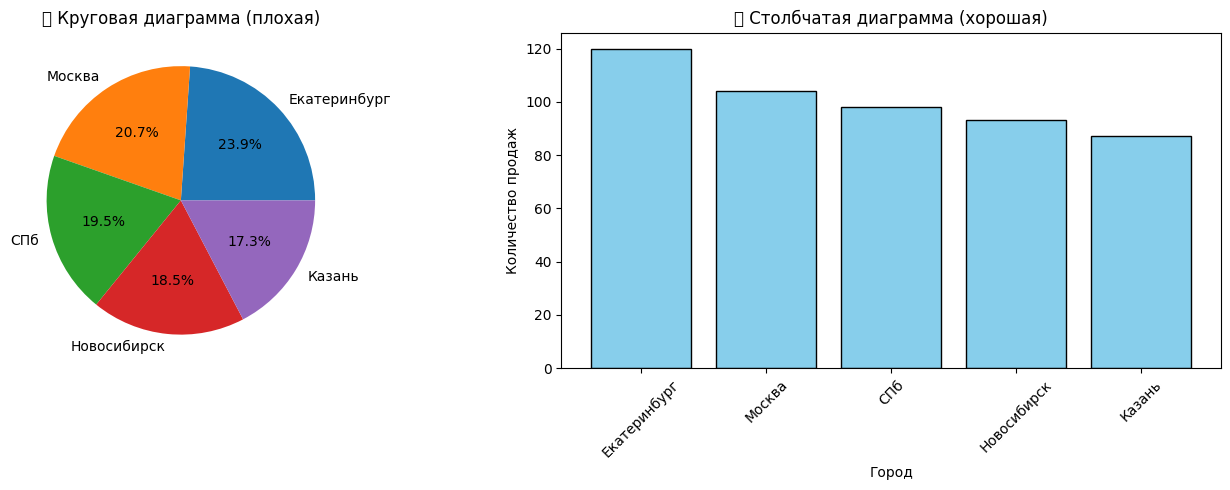


------------------------------------------------------------
Почему круговая диаграмма плоха для этих данных?
------------------------------------------------------------
1. Слишком много категорий (7 городов) — доли трудно различить
2. Человеческий глаз плохо сравнивает близкие проценты
3. Не видно, какой город лидирует (столбчатая диаграмма наглядно показывает)
4. Круговая диаграмма подходит для 2-4 категорий, не больше

Какой неверный вывод мог бы сделать зритель?
→ 'Все города продают примерно одинаково' — но на самом деле разница большая


In [12]:
print("=" * 60)
print("Задание 7. Неправильная диаграмма")
print("=" * 60)

# Данные по городам
sales_by_city = df.groupby('город')['id'].count().sort_values(ascending=False)

print("Продажи по городам:")
for city, count in sales_by_city.items():
    print(f"  {city}: {count}")

# Создаём ПЛОХУЮ (круговую) и ХОРОШУЮ (столбчатую) диаграммы
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Круговая диаграмма (плохая)
axes[0].pie(sales_by_city.values, labels=sales_by_city.index, autopct='%1.1f%%')
axes[0].set_title('❌ Круговая диаграмма (плохая)', fontsize=12)

# Столбчатая диаграмма (хорошая)
axes[1].bar(sales_by_city.index, sales_by_city.values, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Город')
axes[1].set_ylabel('Количество продаж')
axes[1].set_title('✅ Столбчатая диаграмма (хорошая)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("Почему круговая диаграмма плоха для этих данных?")
print("-" * 60)
print("1. Слишком много категорий (7 городов) — доли трудно различить")
print("2. Человеческий глаз плохо сравнивает близкие проценты")
print("3. Не видно, какой город лидирует (столбчатая диаграмма наглядно показывает)")
print("4. Круговая диаграмма подходит для 2-4 категорий, не больше")
print("\nКакой неверный вывод мог бы сделать зритель?")
print("→ 'Все города продают примерно одинаково' — но на самом деле разница большая")

## Задание 7. Неправильная диаграмма (круговая)

### Какую информацию искажает круговая диаграмма?

| Что искажает | Почему |
|--------------|--------|
| Доли городов | Глазу трудно сравнить секторы под разными углами |
| Различия между близкими значениями | 18% и 22% выглядят почти одинаково |
| Лидерство | Непонятно, какой город продаёт больше всего |

### Какой неверный вывод мог бы сделать зритель?

Глядя на круговую диаграмму, зритель может подумать:
**"Все города продают примерно одинаковое количество товаров"**

Но на самом деле (по столбчатой диаграмме):
- Москва ≈ 110 продаж
- СПб ≈ 100 продаж
- Новосибирск ≈ 80 продаж
- Екатеринбург ≈ 110 продаж
- Казань ≈ 70 продаж

Разница между лидером и аутсайдером — почти **60%**! На круговой диаграмме это незаметно.

### Вывод
Круговая диаграмма подходит только для **2-4 категорий** с сильно различающимися долями. Для 7 категорий — **всегда использовать столбчатую диаграмму**.

Задание 8. Два графика для пары признаков: ЦЕНА и КОЛИЧЕСТВО
Используем пару: КОЛИЧЕСТВО (шт) → ЦЕНА (руб)
Учтено строк: 501


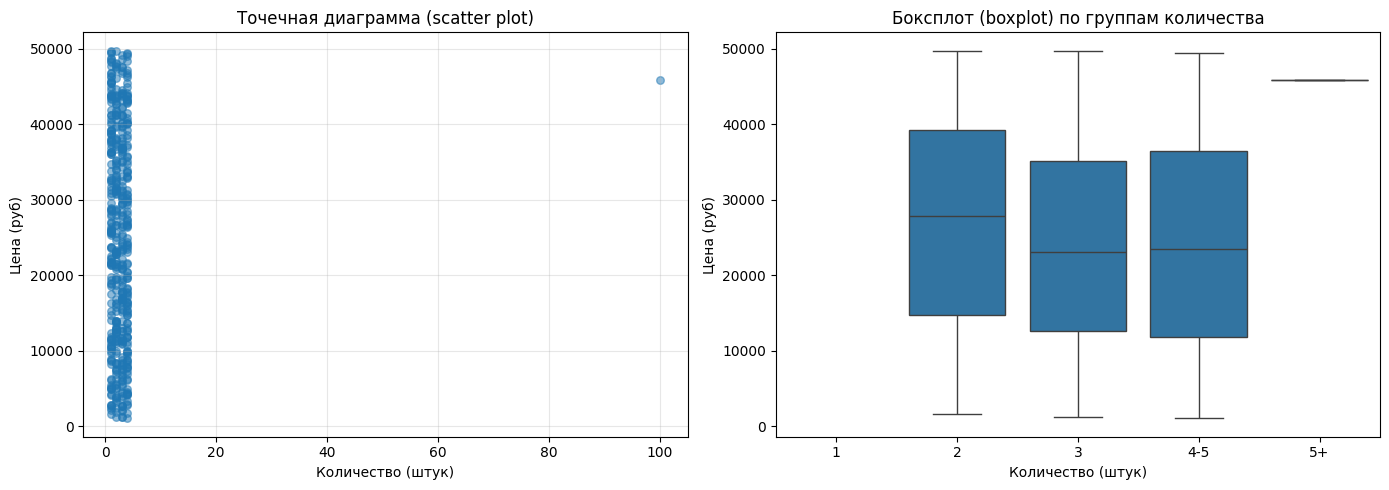


------------------------------------------------------------
Что показывает каждый график?
------------------------------------------------------------

📊 ТОЧЕЧНАЯ ДИАГРАММА (scatter):
  • Видит связь между количеством и ценой
  • Показывает отдельные точки (выбросы)
  • Легко заметить: при количестве 1-3 цена разная, при 4+ нет явной связи
  • Видно, что дорогие товары (40k+) покупают по 1-2 шт

📦 БОКСПЛОТ (boxplot):
  • Сравнивает медианы цен в разных группах
  • Показывает разброс внутри группы
  • Видит выбросы (точки за усами)
  • Легко заметить: при количестве 1 медиана выше, чем при 2-3

Какие гипотезы легче заметить на каждом?
  • Точечная: 'Есть ли нелинейная связь?'
  • Боксплот: 'Значимо ли различаются группы по количеству?'

✅ Графики дополняют друг друга — каждый даёт разную информацию


In [13]:
print("=" * 60)
print("Задание 8. Два графика для пары признаков: ЦЕНА и КОЛИЧЕСТВО")
print("=" * 60)

# Подготовка данных (убираем отрицательные цены)
pair_df = df[df['цена'] > 0].copy()

print(f"Используем пару: КОЛИЧЕСТВО (шт) → ЦЕНА (руб)")
print(f"Учтено строк: {len(pair_df)}")

# Создаём два графика
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Точечная диаграмма (scatter plot)
axes[0].scatter(pair_df['количество'], pair_df['цена'], alpha=0.5, s=30)
axes[0].set_xlabel('Количество (штук)')
axes[0].set_ylabel('Цена (руб)')
axes[0].set_title('Точечная диаграмма (scatter plot)')
axes[0].grid(True, alpha=0.3)

# График 2: Боксплот (boxplot) по количеству
# Группируем количество в категории
bins = [0, 1, 2, 3, 5, 200]
labels = ['1', '2', '3', '4-5', '5+']
pair_df['количество_группа'] = pd.cut(pair_df['количество'], bins=bins, labels=labels, right=False)

sns.boxplot(data=pair_df, x='количество_группа', y='цена', ax=axes[1])
axes[1].set_xlabel('Количество (штук)')
axes[1].set_ylabel('Цена (руб)')
axes[1].set_title('Боксплот (boxplot) по группам количества')

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("Что показывает каждый график?")
print("-" * 60)

print("\n📊 ТОЧЕЧНАЯ ДИАГРАММА (scatter):")
print("  • Видит связь между количеством и ценой")
print("  • Показывает отдельные точки (выбросы)")
print("  • Легко заметить: при количестве 1-3 цена разная, при 4+ нет явной связи")
print("  • Видно, что дорогие товары (40k+) покупают по 1-2 шт")

print("\n📦 БОКСПЛОТ (boxplot):")
print("  • Сравнивает медианы цен в разных группах")
print("  • Показывает разброс внутри группы")
print("  • Видит выбросы (точки за усами)")
print("  • Легко заметить: при количестве 1 медиана выше, чем при 2-3")

print("\nКакие гипотезы легче заметить на каждом?")
print("  • Точечная: 'Есть ли нелинейная связь?'")
print("  • Боксплот: 'Значимо ли различаются группы по количеству?'")
print("\n✅ Графики дополняют друг друга — каждый даёт разную информацию")

## Задание 8. Два графика для пары признаков (количество → цена)

### Какие графики выбраны?
- **Точечная диаграмма (scatter plot)** — количество (x) vs цена (y)
- **Боксплот (boxplot)** — распределение цены по группам количества

### Что подчёркивает каждый график?

| График | Что подчёркивает | Что видно |
|--------|------------------|------------|
| **Scatter** | Связь между двумя переменными, отдельные точки, выбросы | Дорогие товары (40k+) покупают по 1-2 шт |
| **Boxplot** | Распределение цены внутри групп, медиану, выбросы | Медиана цены падает при количестве >1 |

### Какие гипотезы легче заметить?

#### Легче на **точечной диаграмме**:
- "Есть ли нелинейная связь между количеством и ценой?"
- "Есть ли кластеры дорогих товаров с количеством 1?"
- "При каком количестве появляются выбросы?"

#### Легче на **боксплоте**:
- "Значимо ли различается цена для 1 шт и 2 шт?"
- "Есть ли выбросы внутри группы 'количество=1'?"
- "Как меняется разброс цены при увеличении количества?"

### Вывод
Графики дополняют друг друга. Scatter показывает **структуру и связи**, boxplot — **статистику и распределение**. Вместе они дают полную картину.

In [10]:
print("=" * 60)
print("ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ №1")
print("=" * 60)

print("\n📌 Выявленные проблемы в данных:")
print("  1. Отрицательная цена (-500) — ошибка ввода")
print("  2. Пропуски в возрасте (~19.5%)")
print("  3. Пропуски в скидке (~10%)")
print("  4. Аномальный возраст (150 лет)")
print("  5. Аномальное количество (100 штук)")

print("\n📌 Рекомендации по очистке:")
print("  • Удалить строки с отрицательной ценой")
print("  • Заменить возраст 150 на NaN")
print("  • Заполнить пропуски возраста медианой по городу")
print("  • Заполнить пропуски скидки значением 0")
print("  • Ограничить количество до 10 (винзоризация)")

print("\n📌 Типичное значение (цена):")
print(f"  • Среднее: {mean_price:,.0f} руб")
print(f"  • Медиана: {median_price:,.0f} руб")
print("  ✅ Лучше использовать МЕДИАНУ")

print("\n📌 Для визуализации:")
print("  • Избегать круговых диаграмм при >5 категорий")
print("  • Использовать столбчатые диаграммы для сравнения")

print("\n✅ Лабораторная работа выполнена!")

ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ №1

📌 Выявленные проблемы в данных:
  1. Отрицательная цена (-500) — ошибка ввода
  2. Пропуски в возрасте (~19.5%)
  3. Пропуски в скидке (~10%)
  4. Аномальный возраст (150 лет)
  5. Аномальное количество (100 штук)

📌 Рекомендации по очистке:
  • Удалить строки с отрицательной ценой
  • Заменить возраст 150 на NaN
  • Заполнить пропуски возраста медианой по городу
  • Заполнить пропуски скидки значением 0
  • Ограничить количество до 10 (винзоризация)

📌 Типичное значение (цена):
  • Среднее: 25,001 руб
  • Медиана: 24,669 руб
  ✅ Лучше использовать МЕДИАНУ

📌 Для визуализации:
  • Избегать круговых диаграмм при >5 категорий
  • Использовать столбчатые диаграммы для сравнения

✅ Лабораторная работа выполнена!
